In [4]:
import pandas as pd
import numpy as np
df = pd.read_csv("onlinefraud.csv")

In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [7]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [8]:
pd.crosstab(df["type"], df["isFraud"])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [9]:
df.groupby("type")["isFraud"].mean() * 100

type
CASH_IN     0.000000
CASH_OUT    0.183955
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.768799
Name: isFraud, dtype: float64

In [10]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [11]:
df.groupby("isFraud")["amount"].mean()

isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float64

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

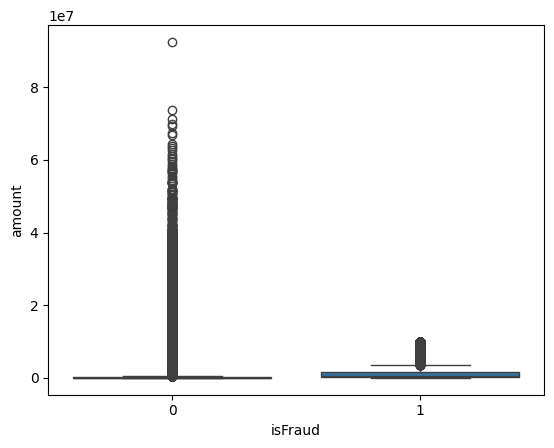

In [16]:
sns.boxplot(x="isFraud", y="amount", data=df)
plt.show()

In [17]:
df.groupby("step")["isFraud"].sum()

step
1      16
2       8
3       4
4      10
5       6
       ..
739    10
740     6
741    22
742    14
743     8
Name: isFraud, Length: 743, dtype: int64

In [18]:
df.groupby("step")["isFraud"].mean()

step
1      0.005908
2      0.007890
3      0.007246
4      0.017699
5      0.009023
         ...   
739    1.000000
740    1.000000
741    1.000000
742    1.000000
743    1.000000
Name: isFraud, Length: 743, dtype: float64

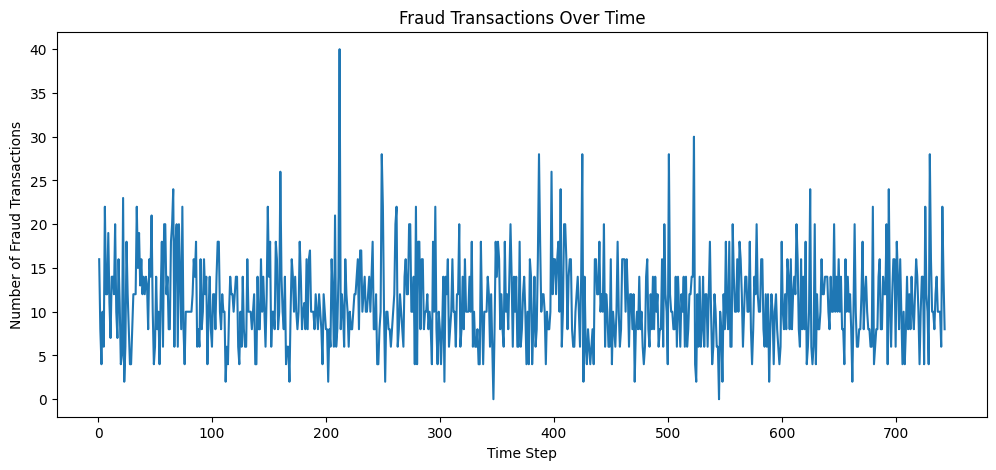

In [19]:
plt.figure(figsize=(12,5))

df.groupby("step")["isFraud"].sum().plot()

plt.xlabel("Time Step")
plt.ylabel("Number of Fraud Transactions")
plt.title("Fraud Transactions Over Time")
plt.show()

In [20]:
df.groupby("isFraud")["oldbalanceOrg"].mean()

isFraud
0    8.328287e+05
1    1.649668e+06
Name: oldbalanceOrg, dtype: float64

In [21]:
df["balance_change"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

In [22]:
df.groupby("isFraud")["balance_change"].mean()

isFraud
0   -2.314152e+04
1    1.457275e+06
Name: balance_change, dtype: float64

In [23]:
df["balance_error"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

In [24]:
df.groupby("isFraud")["oldbalanceDest"].mean()

isFraud
0    1.101421e+06
1    5.442496e+05
Name: oldbalanceDest, dtype: float64

In [25]:
df.groupby("isFraud")["newbalanceDest"].mean()

isFraud
0    1.224926e+06
1    1.279708e+06
Name: newbalanceDest, dtype: float64

In [26]:
df["dest_balance_change"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

In [27]:
df.groupby("isFraud")["dest_balance_change"].mean()

isFraud
0    123504.809994
1    735457.998071
Name: dest_balance_change, dtype: float64

In [28]:
df["nameOrig"].value_counts().describe()

count    6.353307e+06
mean     1.001466e+00
std      3.832002e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: count, dtype: float64

In [29]:
df["nameOrig"].value_counts().head(10)

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [30]:
fraud_df = df[df["isFraud"] == 1]

fraud_df["nameOrig"].value_counts().head(20)

nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
C1579869749    1
C1133500128    1
C2111179588    1
C1400717591    1
C937734682     1
C738609409     1
C1911667833    1
C194800493     1
C1069177491    1
C489467109     1
Name: count, dtype: int64

In [31]:
df.groupby("type")["amount"].mean()

type
CASH_IN     168920.242004
CASH_OUT    176273.964346
DEBIT         5483.665314
PAYMENT      13057.604660
TRANSFER    910647.009645
Name: amount, dtype: float64

In [32]:
df[df["isFraud"] == 1].groupby("type")["amount"].mean()

type
CASH_OUT    1.455103e+06
TRANSFER    1.480892e+06
Name: amount, dtype: float64

In [33]:
df["sender_zero_balance"] = (
    df["newbalanceOrig"] == 0
)

In [34]:
pd.crosstab(
    df["sender_zero_balance"],
    df["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
sender_zero_balance,,
False,99.994188,0.005812
True,99.776898,0.223102


In [35]:
df.isnull().sum()

step                   0
type                   0
amount                 0
nameOrig               0
oldbalanceOrg          0
newbalanceOrig         0
nameDest               0
oldbalanceDest         0
newbalanceDest         0
isFraud                0
isFlaggedFraud         0
balance_change         0
balance_error          0
dest_balance_change    0
sender_zero_balance    0
dtype: int64

In [36]:
(df.isnull().sum() / len(df)) * 100

step                   0.0
type                   0.0
amount                 0.0
nameOrig               0.0
oldbalanceOrg          0.0
newbalanceOrig         0.0
nameDest               0.0
oldbalanceDest         0.0
newbalanceDest         0.0
isFraud                0.0
isFlaggedFraud         0.0
balance_change         0.0
balance_error          0.0
dest_balance_change    0.0
sender_zero_balance    0.0
dtype: float64

In [37]:
df.duplicated().sum()

0

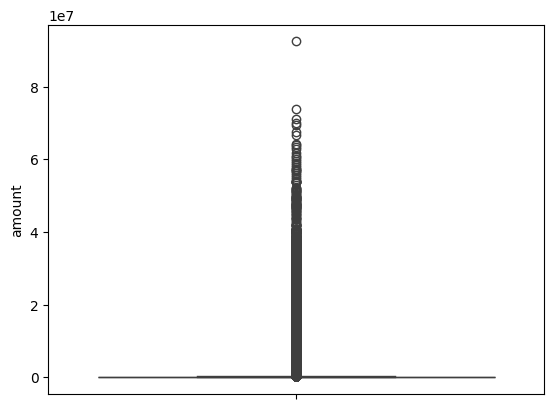

In [38]:
sns.boxplot(y=df["amount"])
plt.show()

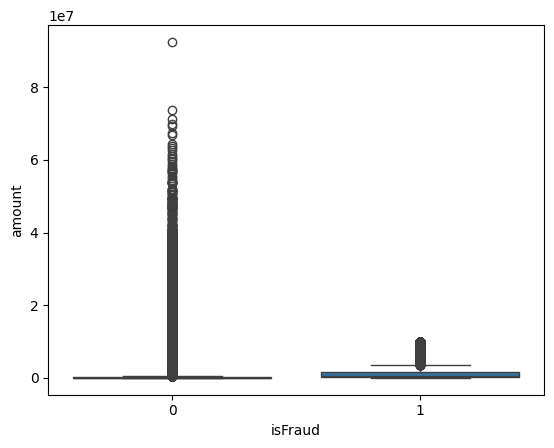

In [39]:
sns.boxplot(
    x="isFraud",
    y="amount",
    data=df
)

plt.show()

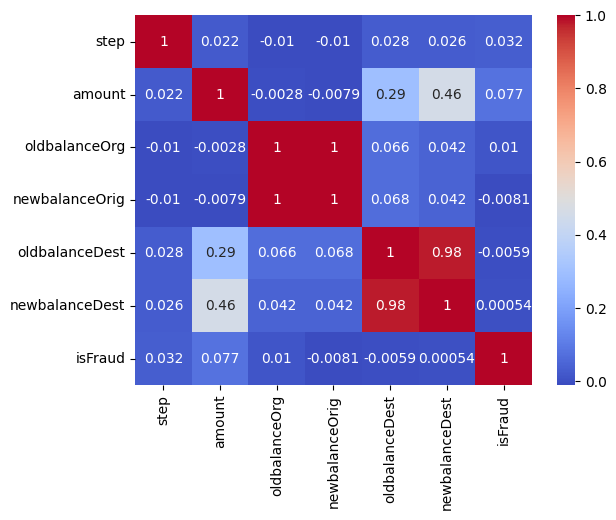

In [40]:
numeric_cols = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud"
]

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.show()